# core

> Create beautiful presentations in Solveit

In [ ]:
#| default_exp core

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
def foo(): pass

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()

# Imports

In [ ]:
#| export
#| export
import re
import json
from pathlib import Path
import nh3

import mistletoe
from mistletoe import Document
from mistletoe.html_renderer import HTMLRenderer

from pygments import highlight as pygments_highlight
from pygments.lexers import PythonLexer
from pygments.formatters import HtmlFormatter

from latex2mathml import converter

from fasthtml.common import *
from dialoghelper.core import find_msgs, curr_dialog, update_msg

import inspect

import html as html_module
import time

In [ ]:
#| export
#| export
def get_slides_cells_from_dialog(include_prompts=False):
    """Get slide cells from the live dialog (after # slides marker)"""
    all_msgs = find_msgs()
    marker_idx = None
    for i, m in enumerate(all_msgs):
        if m['msg_type'] == 'note' and m['content'].strip() == '#| s':
            marker_idx = i
            break
    if marker_idx is None: return []
    allowed_types = ['note', 'code']
    if include_prompts: allowed_types.append('prompt')
    return [m for m in all_msgs[marker_idx + 1:] 
        if m['msg_type'] in allowed_types and not m.get('skipped', 0)]


In [ ]:
#| export
#| export
def load_notebook(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

In [ ]:
#| export
#| export
def get_slides_cells_from_notebook(filepath, dialog_cells):
    """Load notebook cells and attachments filtered to only dialog slides cells"""
    slide_ids = {c['id'].lstrip('_') for c in dialog_cells}
    
    nb_cells = {}
    nb_attachments = {}
    
    for c in load_notebook(filepath)['cells']:
        if c['id'] in slide_ids:
            nb_cells[c['id']] = c
            for att_id, att_data in c.get('attachments', {}).items():
                nb_attachments[att_id] = att_data
    
    return nb_cells, nb_attachments

In [ ]:
#| export
#| export
def group_dialog_cells_by_heading(dialog_slides_cells):
    """Group slide cells by heading (# or ##) - each group becomes one slide"""
    groups, current = [], []
    for cell in dialog_slides_cells:
        is_heading = False
        if cell['msg_type'] == 'note':
            content = cell['content'].strip()
            if content.startswith('## ') or (content.startswith('# ') and not content.startswith('### ')):
                is_heading = True
        if is_heading:
            if current: groups.append(current)
            current = [cell]
        else:
            current.append(cell)
    if current: groups.append(current)
    return groups

In [ ]:
#| export
#| export
THEME_LIGHT = {
    # title slide styles
    'title-heading': 'text-9xl font-bold mb-4', # h1
    'slide-title': 'flex flex-col justify-center items-center text-center p-12 bg-white', 
    # slides styles
    'heading': 'text-8xl font-bold mb-16',        # h2
    'slide-content': 'flex flex-col justify-start items-start pt-16 px-20 pb-12 bg-white overflow-y-auto',
    'paragraph': 'text-5xl mb-6 leading-loose',  
    'list-item': 'text-5xl mb-2 ml-6 list-disc leading-relaxed',
    'code': 'mb-2',
    'output': 'bg-gray-100 p-2 text-sm font-mono',
    'output-image': 'max-w-full max-h-96 object-contain',
    'error': 'bg-red-100 text-red-800 p-2 text-sm font-mono',
    'pygments-style': 'monokai'
}

In [ ]:
#| export
#| export
THEME_DARK = {
    # title styles
    'title-heading': 'text-9xl font-bold mb-4 text-white', # h1
    'slide-title': 'flex flex-col justify-center items-center text-center p-12 bg-gray-900 text-white', 
    # slides styles
    'heading': 'text-8xl font-bold mb-16',  # h2
    'slide-content': 'flex flex-col justify-start items-start pt-16 px-12 pb-12 bg-gray-900 text-white overflow-y-auto overflow-x-hidden',
    'paragraph': 'text-5xl mb-6 leading-loose break-words',   
    'list-item': 'text-5xl mb-10 ml-2 list-disc text-gray-100 break-words',
    'list': 'text-lg ml-2 max-w-full w-full',
    'code': 'mb-2',
    'output': 'bg-gray-800 p-2 text-sm font-mono max-w-full text-gray-100 whitespace-pre-wrap break-words',
    'output-image': 'max-w-full max-h-96 object-contain',
    'error': 'bg-red-900 text-red-200 p-2 text-sm font-mono',
    'pygments-style': 'monokai'
}

In [ ]:
#| export
THEMES = {
    'light': THEME_LIGHT,
    'dark': THEME_DARK
}


In [ ]:
#| export
#| export
def parse_markdown_to_elements(dialog_cell_content, dialog_cell_id, nb_attachments, theme_dict):
    """Parse markdown and return list of FastHTML components"""
    ALLOWED_TAGS = {"p","b","i","em","strong","ul","ol","li","a","br","code","pre",
                "h1","h2","h3","h4","blockquote","table","thead","tbody","tr","td","th",
                "img","div","span","math","mrow","mn","mi","mo","mfrac","msup","msqrt",
                "mtext","mspace","semantics","annotation","msub","mover","munder"}
    ALLOWED_ATTRS = {"a": {"href","class"},"img": {"src","alt","class"},"*": {"class","style","display","id","data-type"}}

    # Handle image attachments
    pattern = r'!\[([^\]]*)\]\(attachment:([^)]+)\)'
    def replace_img(m):
        alt, att_id = m.group(1), m.group(2)
        if att_id in nb_attachments:
            img = nb_attachments[att_id].get('image/png', '')
            return f'<img src="data:image/png;base64,{img}" alt="{html_module.escape(alt)}">'
        return m.group(0)
    content = re.sub(pattern, replace_img, dialog_cell_content)
    
    # Extract LaTeX blocks
    math_blocks = []
    def save_math(m):
        idx = len(math_blocks)
        math_blocks.append(m.group(0))
        return f'<!--MATH_{idx}-->'
    
    content = re.sub(r'\$\$(.*?)\$\$', save_math, content, flags=re.DOTALL)
    content = re.sub(r'\$([^\$]+)\$', save_math, content)
    
    def convert_block(latex_str):
        if latex_str.startswith('$$'):
            latex = latex_str[2:-2]
            mathml = converter.convert(latex)
            mathml = mathml.replace('display="inline"', 'display="block"')
            return f'<div style="text-align: center; margin: 1em 0;">{mathml}</div>'
        else:
            return converter.convert(latex_str[1:-1])
    
    def restore_math(html_str):
        html_str = html_module.unescape(html_str)
        for i, block in enumerate(math_blocks):
            try:
                html_str = html_str.replace(f'<!--MATH_{i}-->', convert_block(block))
            except:
                html_str = html_str.replace(f'<!--MATH_{i}-->', block)
        return html_str
    
    # Parse with mistletoe and wrap in FastHTML
    doc = Document(content)
    elements = []
    idx = 0
    
    with HTMLRenderer() as renderer:
        for child in doc.children:
            if type(child).__name__ == 'List':
                html = restore_math(renderer.render(child))
                html = html.replace('<ul>', '<ul class="list-disc list-inside">')
                html = html.replace('<ol>', '<ol class="list-decimal list-inside">')
                html = html.replace('<li>', f'<li class="{theme_dict["list-item"]}">')
                html = nh3.clean(html, tags=ALLOWED_TAGS, attributes=ALLOWED_ATTRS, link_rel=None)
                el_id = f"el-{idx}-{dialog_cell_id}"
                cls = theme_dict.get('list', '')
                elements.append(Div(NotStr(html), id=el_id, data_type='list', cls=cls))
                idx += 1

            else:
                html = restore_math(renderer.render(child))
                html = nh3.clean(html, tags=ALLOWED_TAGS, attributes=ALLOWED_ATTRS, link_rel=None)
                el_type = type(child).__name__.lower()
                el_id = f"el-{idx}-{dialog_cell_id}"

                if el_type == 'heading' and '<h1>' in html:
                    cls = theme_dict['title-heading']
                else:
                    cls = theme_dict.get(el_type, '')
                
                elements.append(Div(NotStr(html), id=el_id, data_type=el_type, cls=cls))
                idx += 1
    
    return elements


In [ ]:
#| export 
def parse_code_to_elements(dialog_cell_msg, nb_cells, theme_dict):
    """Parse code cell and return list of FastHTML components"""
    dialog_cell_id = dialog_cell_msg['id']
    elements = []
    
    # Syntax highlight the code
    code = dialog_cell_msg['content']
    highlighted = pygments_highlight(code, PythonLexer(), HtmlFormatter(noclasses=True, style=theme_dict['pygments-style']))
    
    # Code element (with optional folding)
    el_id = f"el-code-{dialog_cell_id}"
    if dialog_cell_msg.get('i_collapsed', False):
        code_el = Div(Details(Summary("Code", cls="cursor-pointer font-bold"), NotStr(highlighted)), 
                      id=el_id, data_type="code", cls=theme_dict['code'])
    else:
        code_el = Div(NotStr(highlighted), id=el_id, data_type="code", cls=theme_dict['code'])
    elements.append(code_el)
    
    # Get outputs from notebook
    nb_cell = nb_cells.get(dialog_cell_id.lstrip('_'), {})
    output_parts = []
    for output in nb_cell.get('outputs', []):
        otype = output.get('output_type')
        if otype == 'stream':
            output_parts.append(Pre(''.join(output.get('text', [])), cls=theme_dict['output']))
        elif otype in ['execute_result', 'display_data']:
            data = output.get('data', {})
            if 'image/png' in data:
                output_parts.append(Img(src=f"data:image/png;base64,{data['image/png']}", cls=theme_dict['output-image']))
            elif 'text/plain' in data:
                output_parts.append(Pre(''.join(data['text/plain']), cls=theme_dict['output']))
    
    if output_parts:
        el_id = f"el-output-{dialog_cell_id}"
        if dialog_cell_msg.get('o_collapsed', False):
            output_el = Div(Details(Summary("Output", cls="cursor-pointer font-bold"), *output_parts),
                           id=el_id, data_type="output")
        else:
            output_el = Div(*output_parts, id=el_id, data_type="output")
        elements.append(output_el)
    
    return elements

In [ ]:
#| export
#| export
def create_slide_from_cells(group, nb_cells, nb_attachments, slide_idx, theme_dict):
    """Convert a group of dialog cells into a single slide div with FastHTML components"""
    # Detect if it's a title slide from first cell
    first_content = group[0]['content'].strip()
    is_title = first_content.startswith('# ') and not first_content.startswith('## ')
    
    # Select appropriate slide container class
    slide_base = 'w-[1920px] h-[1080px] box-border'
    slide_class = f"{slide_base} {theme_dict['slide-title']}" if is_title else f"{slide_base} {theme_dict['slide-content']}"

    # Collect all elements from cells
    all_elements = []
    for cell in group:
        if cell['msg_type'] == 'note':
            elements = parse_markdown_to_elements(cell['content'], cell['id'], nb_attachments, theme_dict)
            all_elements.extend(elements)
        elif cell['msg_type'] == 'code':
            elements = parse_code_to_elements(cell, nb_cells, theme_dict)
            all_elements.extend(elements)
    
    # First slide is active, others hidden
    if slide_idx == 0:
        return Div(*all_elements, data_slide=slide_idx, cls=f"{slide_class} active")
    else:
        return Div(*all_elements, data_slide=slide_idx, cls=f"{slide_class} hidden")

In [ ]:
#| export
#| export
def generate_slides_html(groups, nb_cells, nb_attachments, theme_dict):
    """Generate complete HTML document with all slides using FastHTML"""
    
    # Build all slides
    slides = [create_slide_from_cells(group, nb_cells, nb_attachments, i, theme_dict) 
              for i, group in enumerate(groups)]
    
    # CSS for slide visibility
    slide_css = """
        [data-slide] { transition: opacity 0.3s; }
        [data-slide].hidden { display: none; opacity: 0; }
        [data-slide].active { display: flex; opacity: 1; }
    """
 
    # JavaScript for navigation
    nav_js = """
        let currentSlide = 0;
        const slides = document.querySelectorAll('[data-slide]');
        
        function showSlide(n) {
            slides[currentSlide].classList.remove('active');
            slides[currentSlide].classList.add('hidden');
            currentSlide = Math.max(0, Math.min(n, slides.length - 1));
            slides[currentSlide].classList.remove('hidden');
            slides[currentSlide].classList.add('active');
            updateCounter();
        }
        
        document.addEventListener('keydown', (e) => {
            if (e.key === 'ArrowRight') showSlide(currentSlide + 1);
            if (e.key === 'ArrowLeft') showSlide(currentSlide - 1);
            if (e.key === 'f') document.documentElement.requestFullscreen();
        

            if (e.key === 'ArrowDown') {
                const active = document.querySelector('[data-slide].active');
                active.scrollBy({ top: 100, behavior: 'smooth' });
            }
            if (e.key === 'ArrowUp') {
                const active = document.querySelector('[data-slide].active');
                active.scrollBy({ top: -100, behavior: 'smooth' });
            }
            });
            document.getElementById('prev-btn').onclick = () => showSlide(currentSlide - 1);
            document.getElementById('next-btn').onclick = () => showSlide(currentSlide + 1);

            // Update counter
            function updateCounter() {
                document.getElementById('slide-counter').textContent = 
                    `${currentSlide + 1} / ${slides.length}`;
            }
            updateCounter();

    """
    
    scale_js = """
        (() => {
        const DESIGN_WIDTH = 1920, DESIGN_HEIGHT = 1080;
        const stage = document.getElementById("stage");
        const viewport = document.getElementById("viewport");

        function rescale() {
            const vw = viewport.clientWidth, vh = viewport.clientHeight;
            const scale = Math.min(vw / DESIGN_WIDTH, vh / DESIGN_HEIGHT);
            stage.style.transform = `scale(${scale})`;
            stage.style.width = `${DESIGN_WIDTH}px`;
            stage.style.height = `${DESIGN_HEIGHT}px`;
            stage.style.left = `${(vw - DESIGN_WIDTH * scale) / 2}px`;
            stage.style.top = `${(vh - DESIGN_HEIGHT * scale) / 2}px`;
        }

        new ResizeObserver(rescale).observe(viewport);
        rescale();
        })();
    """

    try:
        import sslides
        tailwind_js = (Path(sslides.__file__).parent / 'assets' / 'tailwind-browser.js').read_text()
    except:
        # Fallback for local development
        tailwind_js = (Path('../sslides/assets/tailwind-browser.js')).read_text()
    
    nav_controls = Div(
        Button("<", id="prev-btn", cls="text-2xl cursor-pointer hover:text-gray-300"),
        Span("1 / 13", id="slide-counter", cls="text-lg"),
        Button(">", id="next-btn", cls="text-2xl cursor-pointer hover:text-gray-300"),
        id="nav-controls",
        cls="fixed bottom-4 right-4 opacity-0 hover:opacity-100 transition-opacity bg-black/50 rounded-lg px-4 py-2 flex items-center gap-4 text-white"
        )


    return Html(
        Head(
            Meta(charset="utf-8"),
            Script(NotStr(tailwind_js)),
            Title("Presentation"),
           
            Style(slide_css)
        ),
        Body(
            Div(
                Div(
                    Div(*slides, id="slides-container"),
                    id="stage", cls="absolute left-0 top-0 origin-top-left"
                ),
                id="viewport", cls="w-screen h-screen relative overflow-hidden"
            ),

            nav_controls,
            Script(nav_js),
            Script(scale_js),
            Script("window.onload = () => window.parent.postMessage({type: 'slides_ready'}, '*');"),
            cls="m-0 bg-black overflow-hidden"
        )
    )

In [ ]:
#| export
#| export
def sshow(theme='dark'):
    dialog_slides_cells = get_slides_cells_from_dialog()
    nb_cells, nb_attachments = get_slides_cells_from_notebook(
        Path(curr_dialog()['name']).name + '.ipynb', dialog_slides_cells)

    groups = group_dialog_cells_by_heading(dialog_slides_cells)
    
    theme_dict = theme if isinstance(theme, dict) else THEMES.get(theme, THEME_DARK)
    html_doc = generate_slides_html(groups, nb_cells, nb_attachments, theme_dict)
    html_content = to_xml(html_doc)

    # Save to file
    Path('sslides.html').write_text(html_content)

    # Display from file content
    # show(Iframe(srcdoc=html_content, width="100%", style="aspect-ratio: 16/9; max-width: 800px;"))
    # time.sleep(0.5) 
    show(Iframe(srcdoc=html_content, width="100%", 
                style="aspect-ratio: 16/9; max-width: 800px; background: #111;",
                onload="window.addEventListener('message', e => { if(e.data.type === 'slides_ready') { /* trigger skip */ } })"))


    time.sleep(1)


    caller_globals = inspect.currentframe().f_back.f_globals
    update_msg(id=caller_globals['__msg_id'], skipped=1)

In [ ]:
#| export
#| export
def ssave(output_path='presentation.html', theme='dark'):
    dialog_slides_cells = get_slides_cells_from_dialog()
    nb_cells, nb_attachments = get_slides_cells_from_notebook(
        Path(curr_dialog()['name']).name + '.ipynb', dialog_slides_cells)

    groups = group_dialog_cells_by_heading(dialog_slides_cells)
    
    theme_dict = theme if isinstance(theme, dict) else THEMES.get(theme, THEME_DARK)
    html_doc = generate_slides_html(groups, nb_cells, nb_attachments, theme_dict)
    html_content = to_xml(html_doc)
    
    Path(output_path).write_text(html_content)
    print(f"Saved to {output_path} ({Path(output_path).stat().st_size / 1024:.1f} KB)")
    time.sleep(2)
    caller_globals = inspect.currentframe().f_back.f_globals
    update_msg(id=caller_globals['__msg_id'], skipped=1)
    return output_path

In [ ]:
# #|eval: false
# sshow()

In [ ]:
import sslides
print(sslides.__version__)

In [ ]:
import importlib.metadata
print(importlib.metadata.version('sslides'))

# Introducing sslides

## What is sslides

A tool for creating beautiful presentations from your solveit dialogs and research.
- At the end of dialog create your slides 
- `#| s` marks the begining of slides
- All Markdown and code cells below will be in slides
- Code and code output hidden in dialog will be hidden in the  slides

## Content Suported
- Markdown
- Bullet lists
- Latex Math
- Attachments from screenshots
- Code - highlighted by Pygments

```
my_theme = {
    # title slide styles
    'title-heading': 'text-9xl font-serif font-bold mb-4 text-blue-600',  # h1 - blue serif
    'slide-title': 'flex flex-col justify-center items-center text-center p-12 bg-gray-300',  # gray background
    
    # regular slides styles
    'heading': 'text-8xl font-serif font-bold mb-16 text-blue-600',  # h2 - blue serif
    'slide-content': 'flex flex-col justify-start items-start pt-16 px-12 pb-12 bg-gray-300 text-black overflow-y-auto overflow-x-hidden',  # gray bg, black text
    'paragraph': 'text-5xl mb-6 leading-loose break-words text-black',   
    'list-item': 'text-5xl mb-10 ml-2 list-disc text-black break-words',
    'list': 'text-lg ml-2 max-w-full w-full',
    'code': 'mb-2',
    'output': 'bg-gray-100 p-2 text-sm font-mono max-w-full text-black whitespace-pre-wrap break-words',
    'output-image': 'max-w-full max-h-96 object-contain',
    'error': 'bg-red-200 text-red-900 p-2 text-sm font-mono',
    'pygments-style': 'default'  # lighter syntax highlighting for gray background
}

```

## Latex

### Scaled Dot-Product Attention

The attention mechanism from "Attention is All You Need":

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where $Q$ is queries, $K$ is keys, $V$ is values, and $d_k$ is the dimension of the keys.

## Attachments


| 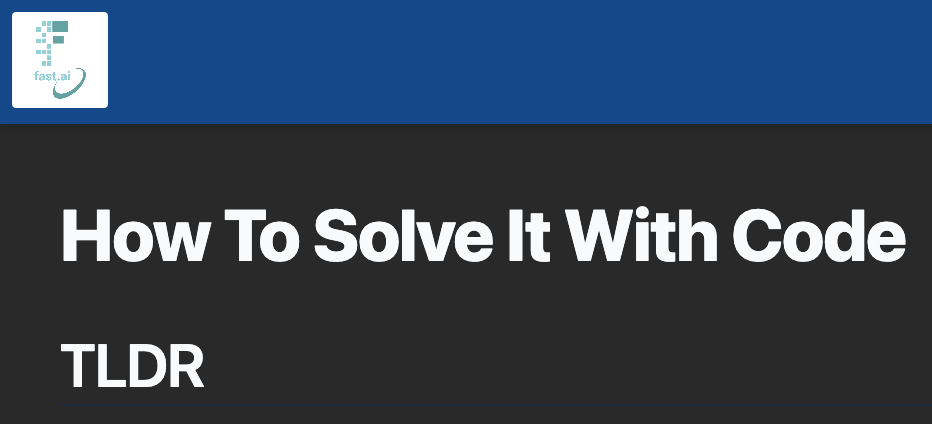 | 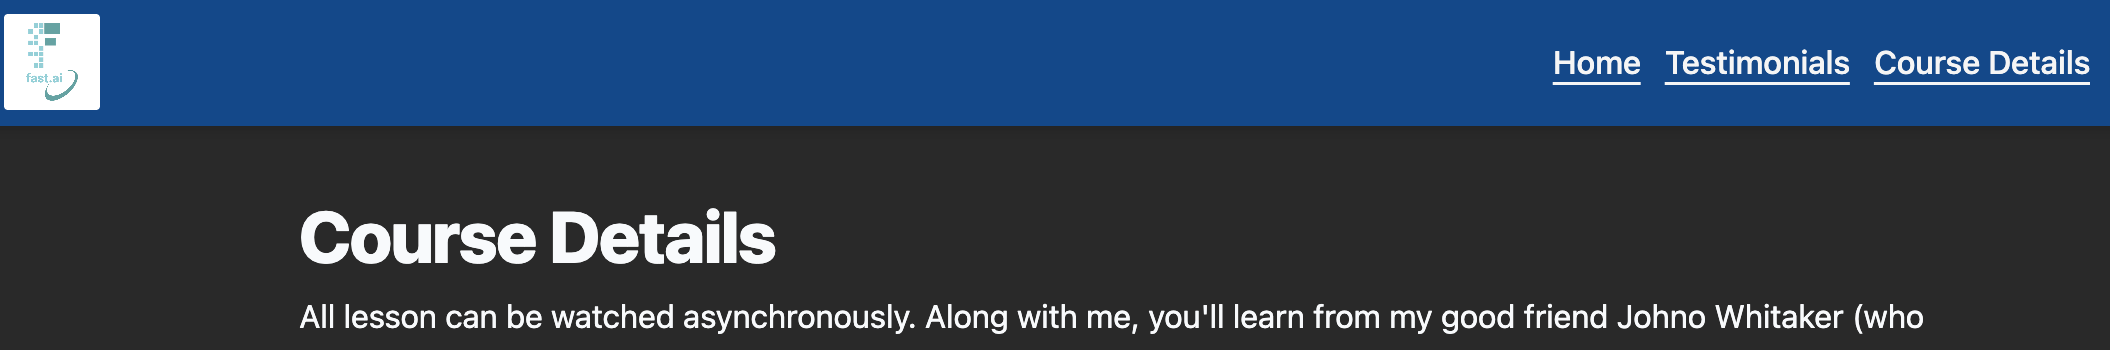 |
|---|---|


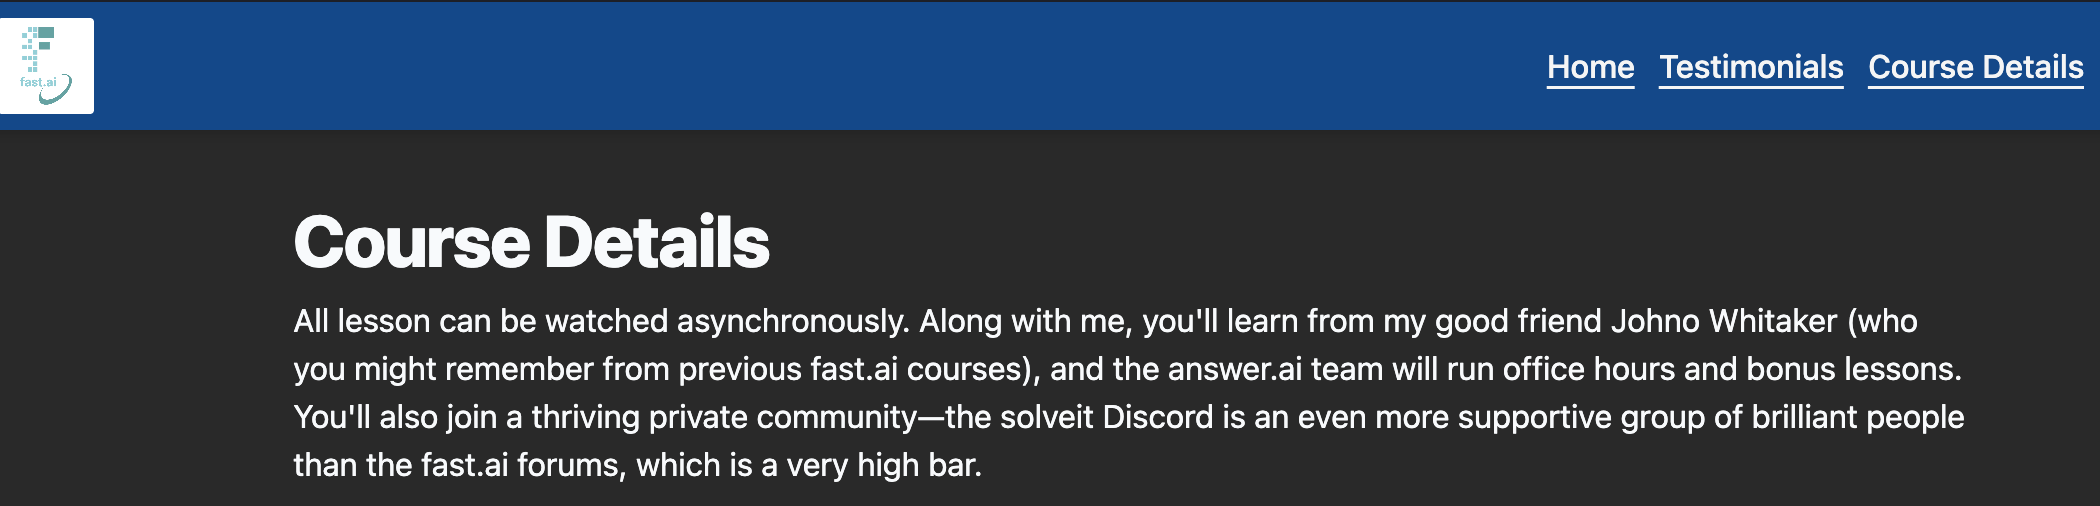
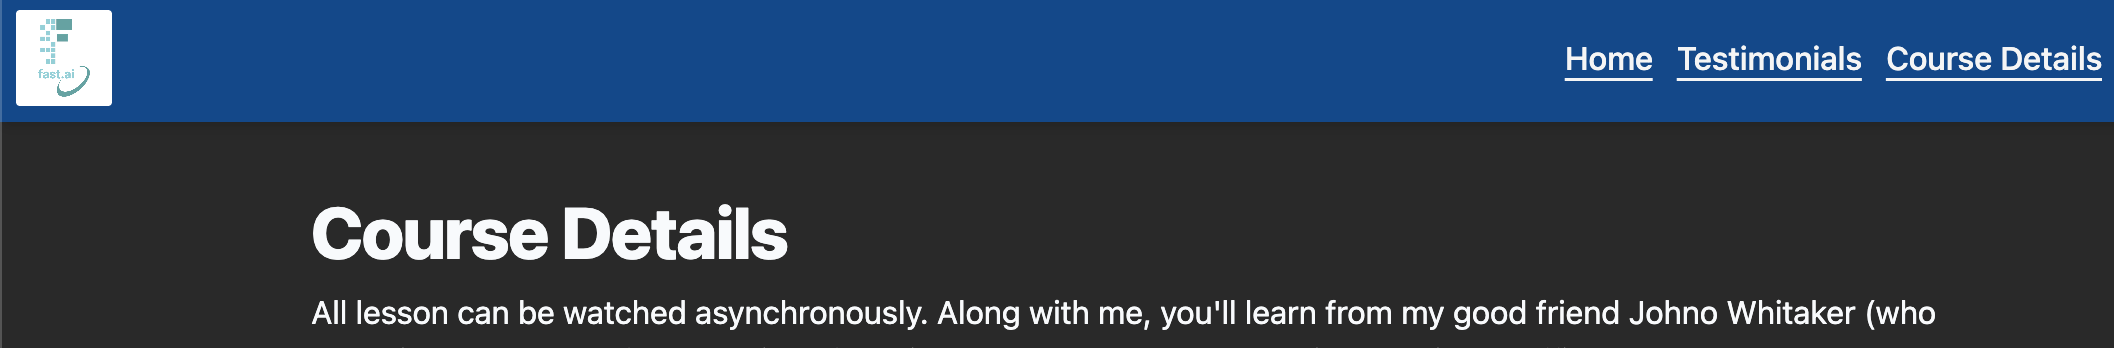

## Plots

### Activation Functions Comparisons
- Code hidden

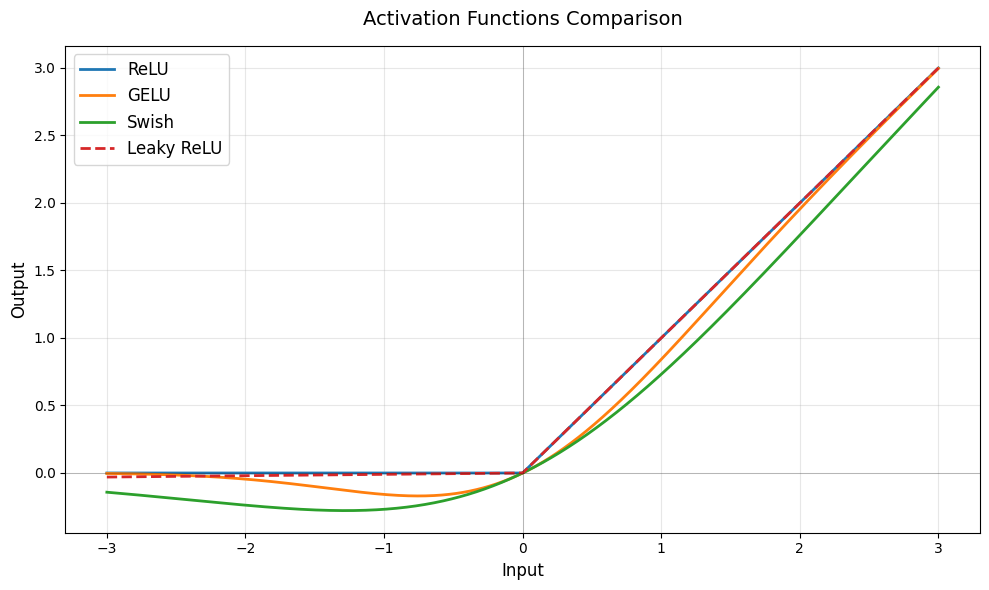

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-3, 3, 1000)

# Activation functions
relu = np.maximum(0, x)
gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
swish = x / (1 + np.exp(-x))
leaky_relu = np.where(x > 0, x, 0.01 * x)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, relu, label='ReLU', linewidth=2)
ax.plot(x, gelu, label='GELU', linewidth=2)
ax.plot(x, swish, label='Swish', linewidth=2)
ax.plot(x, leaky_relu, label='Leaky ReLU', linewidth=2, linestyle='--')

ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_xlabel('Input', fontsize=12)
ax.set_ylabel('Output', fontsize=12)
ax.set_title('Activation Functions Comparison', fontsize=14, pad=15)
plt.tight_layout()
plt.show()